# Customer Churn Prediction & Analytics Platform

# Notebook 03 – Exploratory Data Analysis (EDA)

## Objective

The objective of this notebook is to explore the cleaned customer churn dataset, identify patterns, understand customer behavior, and derive business insights through visualizations.



In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
processed_path = Path("../data/processed/customer_churn_clean.csv")

df = pd.read_csv(processed_path)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape

(7032, 21)

# 1. Customer Churn Distribution

This visualization shows the distribution of customers who stayed versus customers who churned.

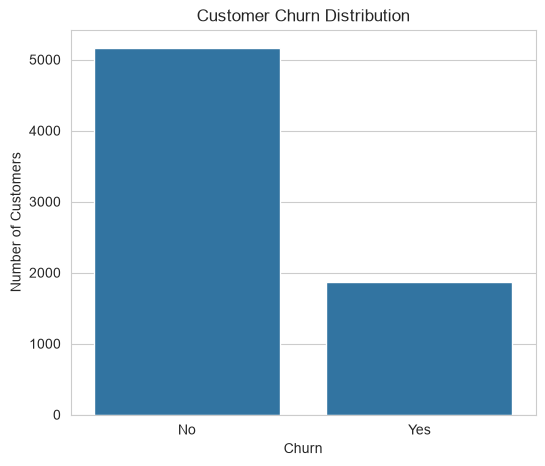

In [7]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [8]:
churn_percentage = (
    df["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(churn_percentage)

Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64


## Business Insight

Approximately **27% of customers** have churned.

This indicates that customer attrition is a significant business concern and justifies building a predictive model to identify high-risk customers before they leave.

# 2. Gender vs Churn

This analysis examines whether customer churn differs between male and female customers.

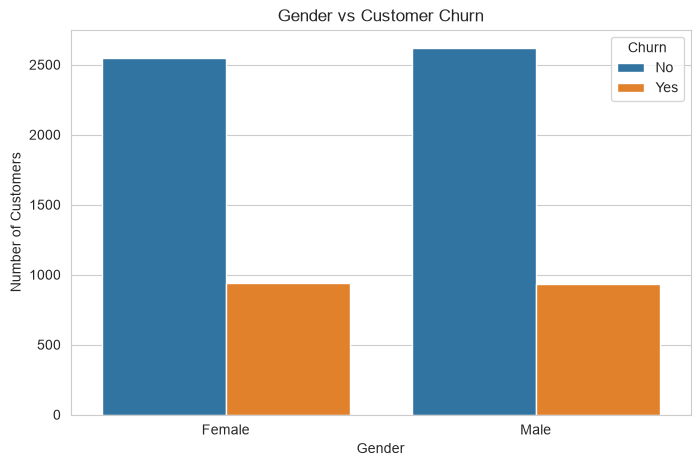

In [9]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="gender",
    hue="Churn"
)

plt.title("Gender vs Customer Churn")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

In [10]:
gender_churn = pd.crosstab(
    df["gender"],
    df["Churn"],
    normalize="index"
) * 100

gender_churn.round(2)

Churn,No,Yes
gender,,
Female,73.04,26.96
Male,73.80,26.20


## Business Insight

The churn rate is very similar for both male and female customers.

This suggests that gender is **not a strong factor** influencing customer churn. Retention strategies should therefore focus on other customer characteristics such as contract type, tenure, or monthly charges.

# 3. Senior Citizen vs Churn

This analysis explores whether senior citizens exhibit different churn behavior compared to non-senior customers.

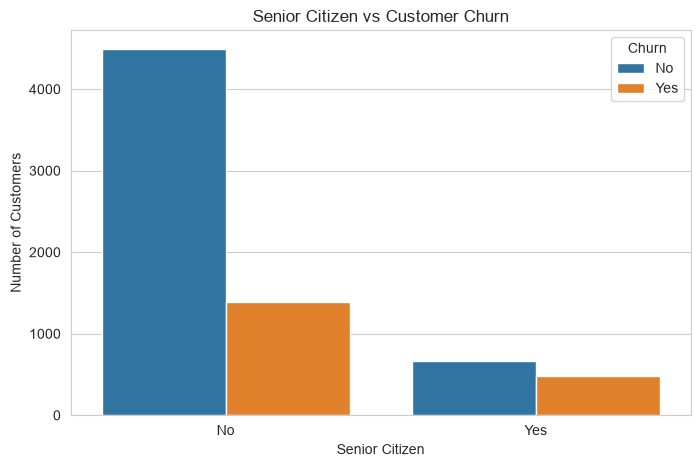

In [11]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="SeniorCitizen",
    hue="Churn"
)

plt.title("Senior Citizen vs Customer Churn")
plt.xlabel("Senior Citizen")
plt.ylabel("Number of Customers")

plt.show()

In [12]:
senior_churn = pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100

senior_churn.round(2)

Churn,No,Yes
SeniorCitizen,,
No,76.35,23.65
Yes,58.32,41.68


## Business Insight

Compare the churn percentages of senior and non-senior customers.

If senior citizens show a higher churn rate, this segment may require targeted customer retention initiatives.

In [13]:
gender_churn.round(2).style.format("{:.2f}%")

Churn,No,Yes
gender,,
Female,73.04%,26.96%
Male,73.80%,26.20%


In [14]:
senior_churn.round(2).style.format("{:.2f}%")

Churn,No,Yes
SeniorCitizen,,
No,76.35%,23.65%
Yes,58.32%,41.68%


# 4. Contract Type vs Churn

Contract duration is one of the strongest indicators of customer retention.

This analysis investigates whether customers with different contract types exhibit different churn behavior.

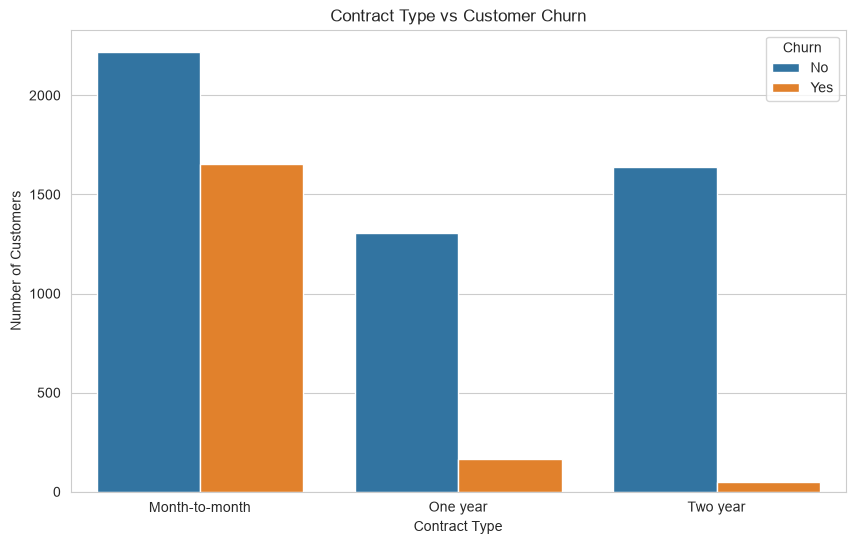

In [15]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Contract Type vs Customer Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

In [16]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn.round(2)

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.72,11.28
Two year,97.15,2.85


## Business Insight

Customers on **Month-to-month** contracts exhibit the highest churn rate.

Customers with **One year** and **Two year** contracts have significantly lower churn.

This suggests that longer-term contracts improve customer retention and reduce churn.

### Recommendation

Introduce incentives that encourage customers to move from Month-to-month contracts to annual or two-year contracts.

Examples:

- Discount on yearly plans
- Loyalty rewards
- Free premium services
- Contract renewal offers

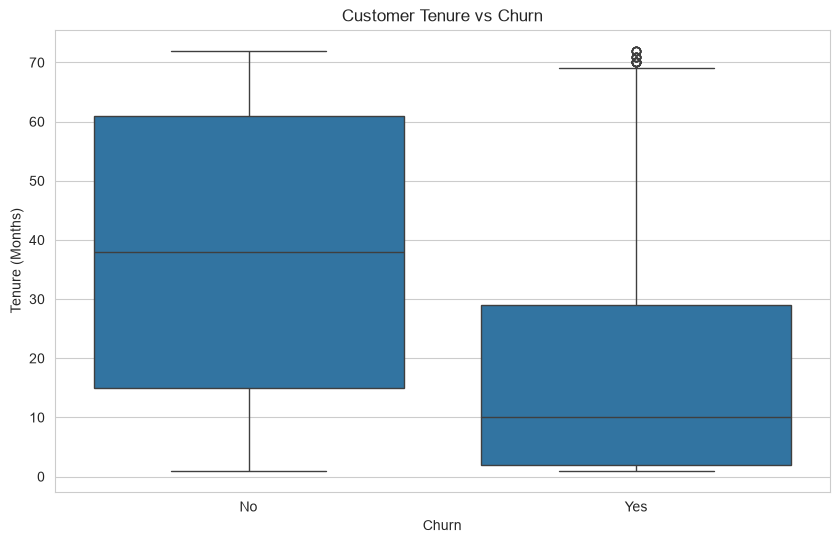

In [17]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Customer Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

In [18]:
df.groupby("Churn")["tenure"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,37.65,24.08,1.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.98,19.53,1.0,2.0,10.0,29.0,72.0


## Business Insight

Customers who churn generally have significantly lower tenure.

This indicates that customers are more likely to leave during the early stages of their relationship with the company.

Retention efforts should therefore focus on onboarding and the first few months of the customer lifecycle.

### Recommendation

Develop an onboarding retention program for new customers.

Possible initiatives include:

- Welcome offers
- Free technical support
- Early engagement campaigns
- Personalized onboarding emails

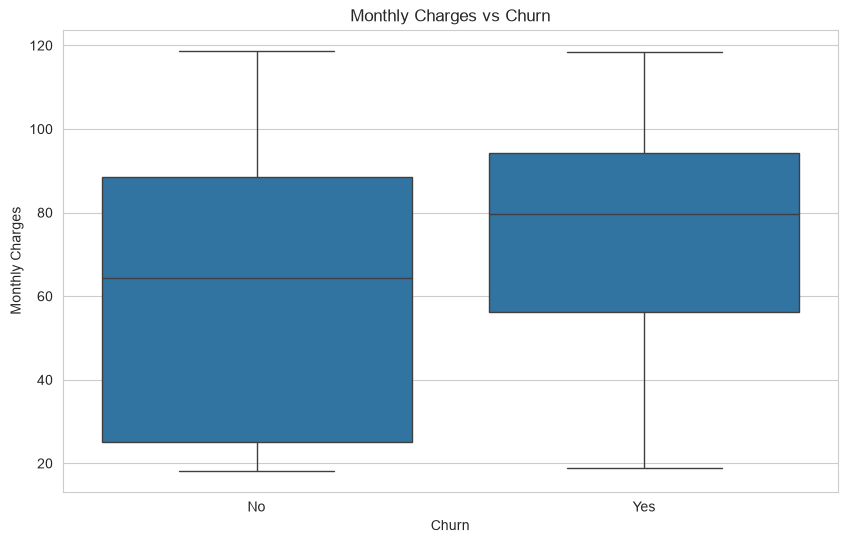

In [19]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [20]:
df.groupby("Churn")["MonthlyCharges"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,61.31,31.09,18.25,25.10,64.45,88.48,118.75
Yes,1869.0,74.44,24.67,18.85,56.15,79.65,94.20,118.35


## Business Insight

Customers with higher monthly charges tend to churn more frequently.

This suggests that pricing may influence customer retention.

Customers paying higher monthly fees may perceive lower value or may switch to competitors offering similar services at lower prices.

## Business Insight

Customers with higher monthly charges tend to churn more frequently.

This suggests that pricing may influence customer retention.

Customers paying higher monthly fees may perceive lower value or may switch to competitors offering similar services at lower prices.

### Recommendation

Identify high-paying customers at risk of churn and offer:

- Discounted renewal plans
- Personalized offers
- Loyalty benefits
- Premium customer support

# 5. Internet Service vs Churn

This analysis examines whether customers using different internet service types exhibit different churn behavior.

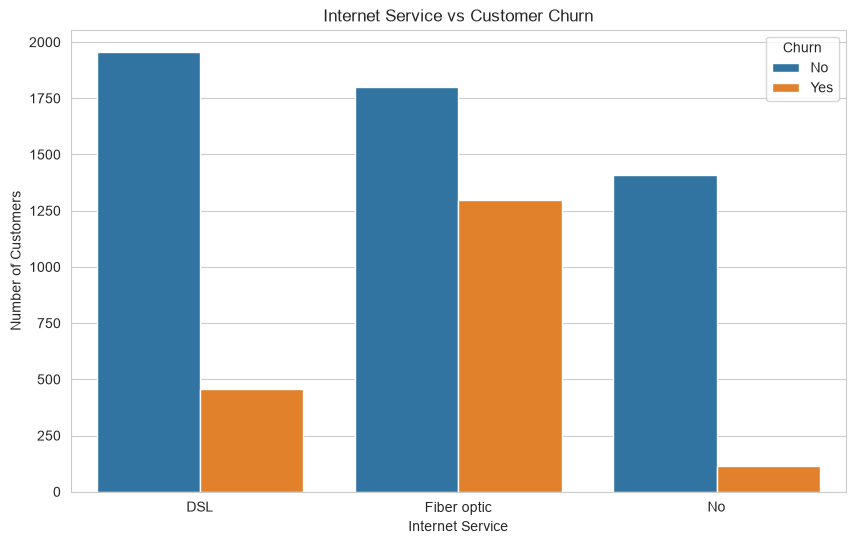

In [21]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.title("Internet Service vs Customer Churn")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

In [22]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet_churn.round(2)

Churn,No,Yes
InternetService,,
DSL,81.00,19.00
Fiber optic,58.11,41.89
No,92.57,7.43


## Business Insight

Customers using Fiber Optic internet exhibit a higher churn rate than DSL customers.

Although Fiber Optic offers faster internet speeds, higher pricing or customer expectations may contribute to increased churn.

This customer segment should be investigated further to identify the primary reasons for dissatisfaction.

### Recommendation

Develop retention campaigns specifically for Fiber Optic customers.

Possible initiatives include:

- Personalized discounts
- Service quality improvements
- Customer satisfaction surveys
- Premium support services

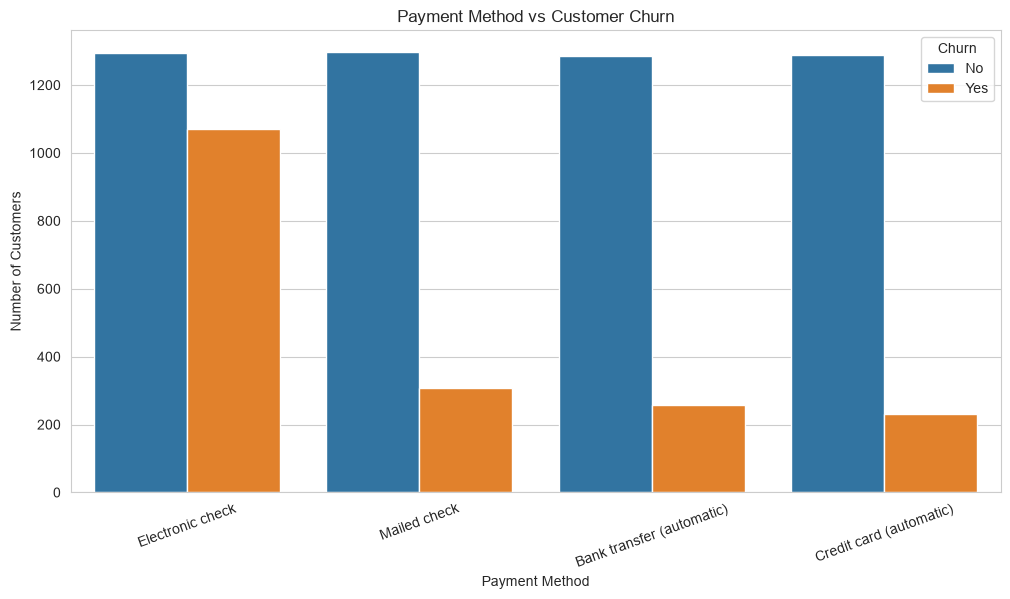

In [23]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

plt.xticks(rotation=20)

plt.title("Payment Method vs Customer Churn")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.show()

In [24]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

payment_churn.round(2)

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.27,16.73
Credit card (automatic),84.75,15.25
Electronic check,54.71,45.29
Mailed check,80.80,19.20


## Business Insight

Customers using Electronic Check exhibit the highest churn rate.

This may indicate lower customer loyalty or differences in customer payment behavior.

The company should investigate why this payment segment experiences higher churn.

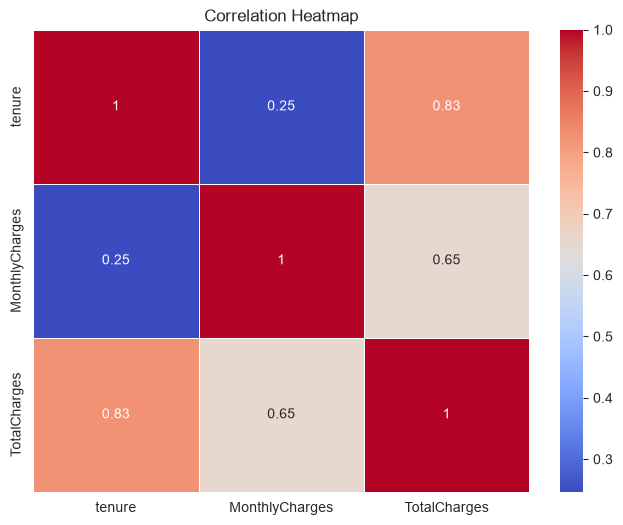

In [25]:
plt.figure(figsize=(8,6))

correlation = df.select_dtypes(include=["number"]).corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

## Business Insight

The heatmap illustrates the relationships among numerical variables.

Strong correlations may indicate important predictors for the machine learning model, while weak correlations suggest independent features.

# Executive Summary

### Key Findings

1. Approximately **27%** of customers have churned.

2. Month-to-month contracts have the highest churn rate.

3. Customers with shorter tenure are significantly more likely to churn.

4. Customers paying higher monthly charges show increased churn.

5. Fiber Optic customers demonstrate higher churn than DSL customers.

6. Electronic Check users have the highest churn among payment methods.

### Business Recommendations

- Encourage customers to switch to long-term contracts.
- Focus retention efforts on new customers.
- Monitor high-value customers with elevated monthly charges.
- Improve customer experience for Fiber Optic users.
- Design targeted campaigns for Electronic Check customers.